In [46]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

Read files

In [17]:
data = Path("../data/netflix.csv")
df = pd.read_csv(data)

In [20]:
df

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458333,458333,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN
458334,458334,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1,NaN,NaN,NaN,NaN,NaN,NaN
458335,458335,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1,TV (English),2.0,62150000.0,NaN,NaN,1.0
458336,458336,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1,TV (Non-English),10.0,9140000.0,NaN,NaN,1.0


In [61]:
# Overview
df.describe()

,Unnamed: 0,country_weekly_rank,country_cumulative_weeks_in_top_10,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
count,458338.000000,458338.000000,458338.000000,306075.000000,3.060750e+05,180673.000000,1.806730e+05,306075.000000
mean,229168.500000,5.499784,3.441938,3.688325,3.181426e+07,243.081659,8.229346e+06,3.080189
std,132310.928177,2.872254,6.056793,2.546472,3.855473e+07,183.437471,8.069365e+06,3.575171
min,0.000000,1.000000,1.000000,1.000000,8.000000e+05,0.000000,7.000000e+05,1.000000
25%,114584.250000,3.000000,1.000000,2.000000,1.155000e+07,105.000000,3.300000e+06,1.000000
50%,229168.500000,5.000000,2.000000,3.000000,2.090000e+07,160.002000,5.500000e+06,2.000000
75%,343752.750000,8.000000,3.000000,5.000000,3.805000e+07,354.000000,9.900000e+06,3.000000
max,458337.000000,10.000000,127.000000,10.000000,5.717600e+08,2854.998000,6.800000e+07,39.000000


In [64]:
# Check total null values by column
df.isna().sum()

Unnamed: 0                                 0
country_name                               0
country_iso2                               0
week                                       0
country_category                           0
country_weekly_rank                        0
show_title                                 0
season_title                          234434
country_cumulative_weeks_in_top_10         0
global_category                       152263
global_weekly_rank                    152263
global_weekly_hours_viewed            152263
runtime                               277665
global_weekly_views                   277665
global_cumulative_weeks_in_top_10     152263
dtype: int64

Seaborn pairplot for overview

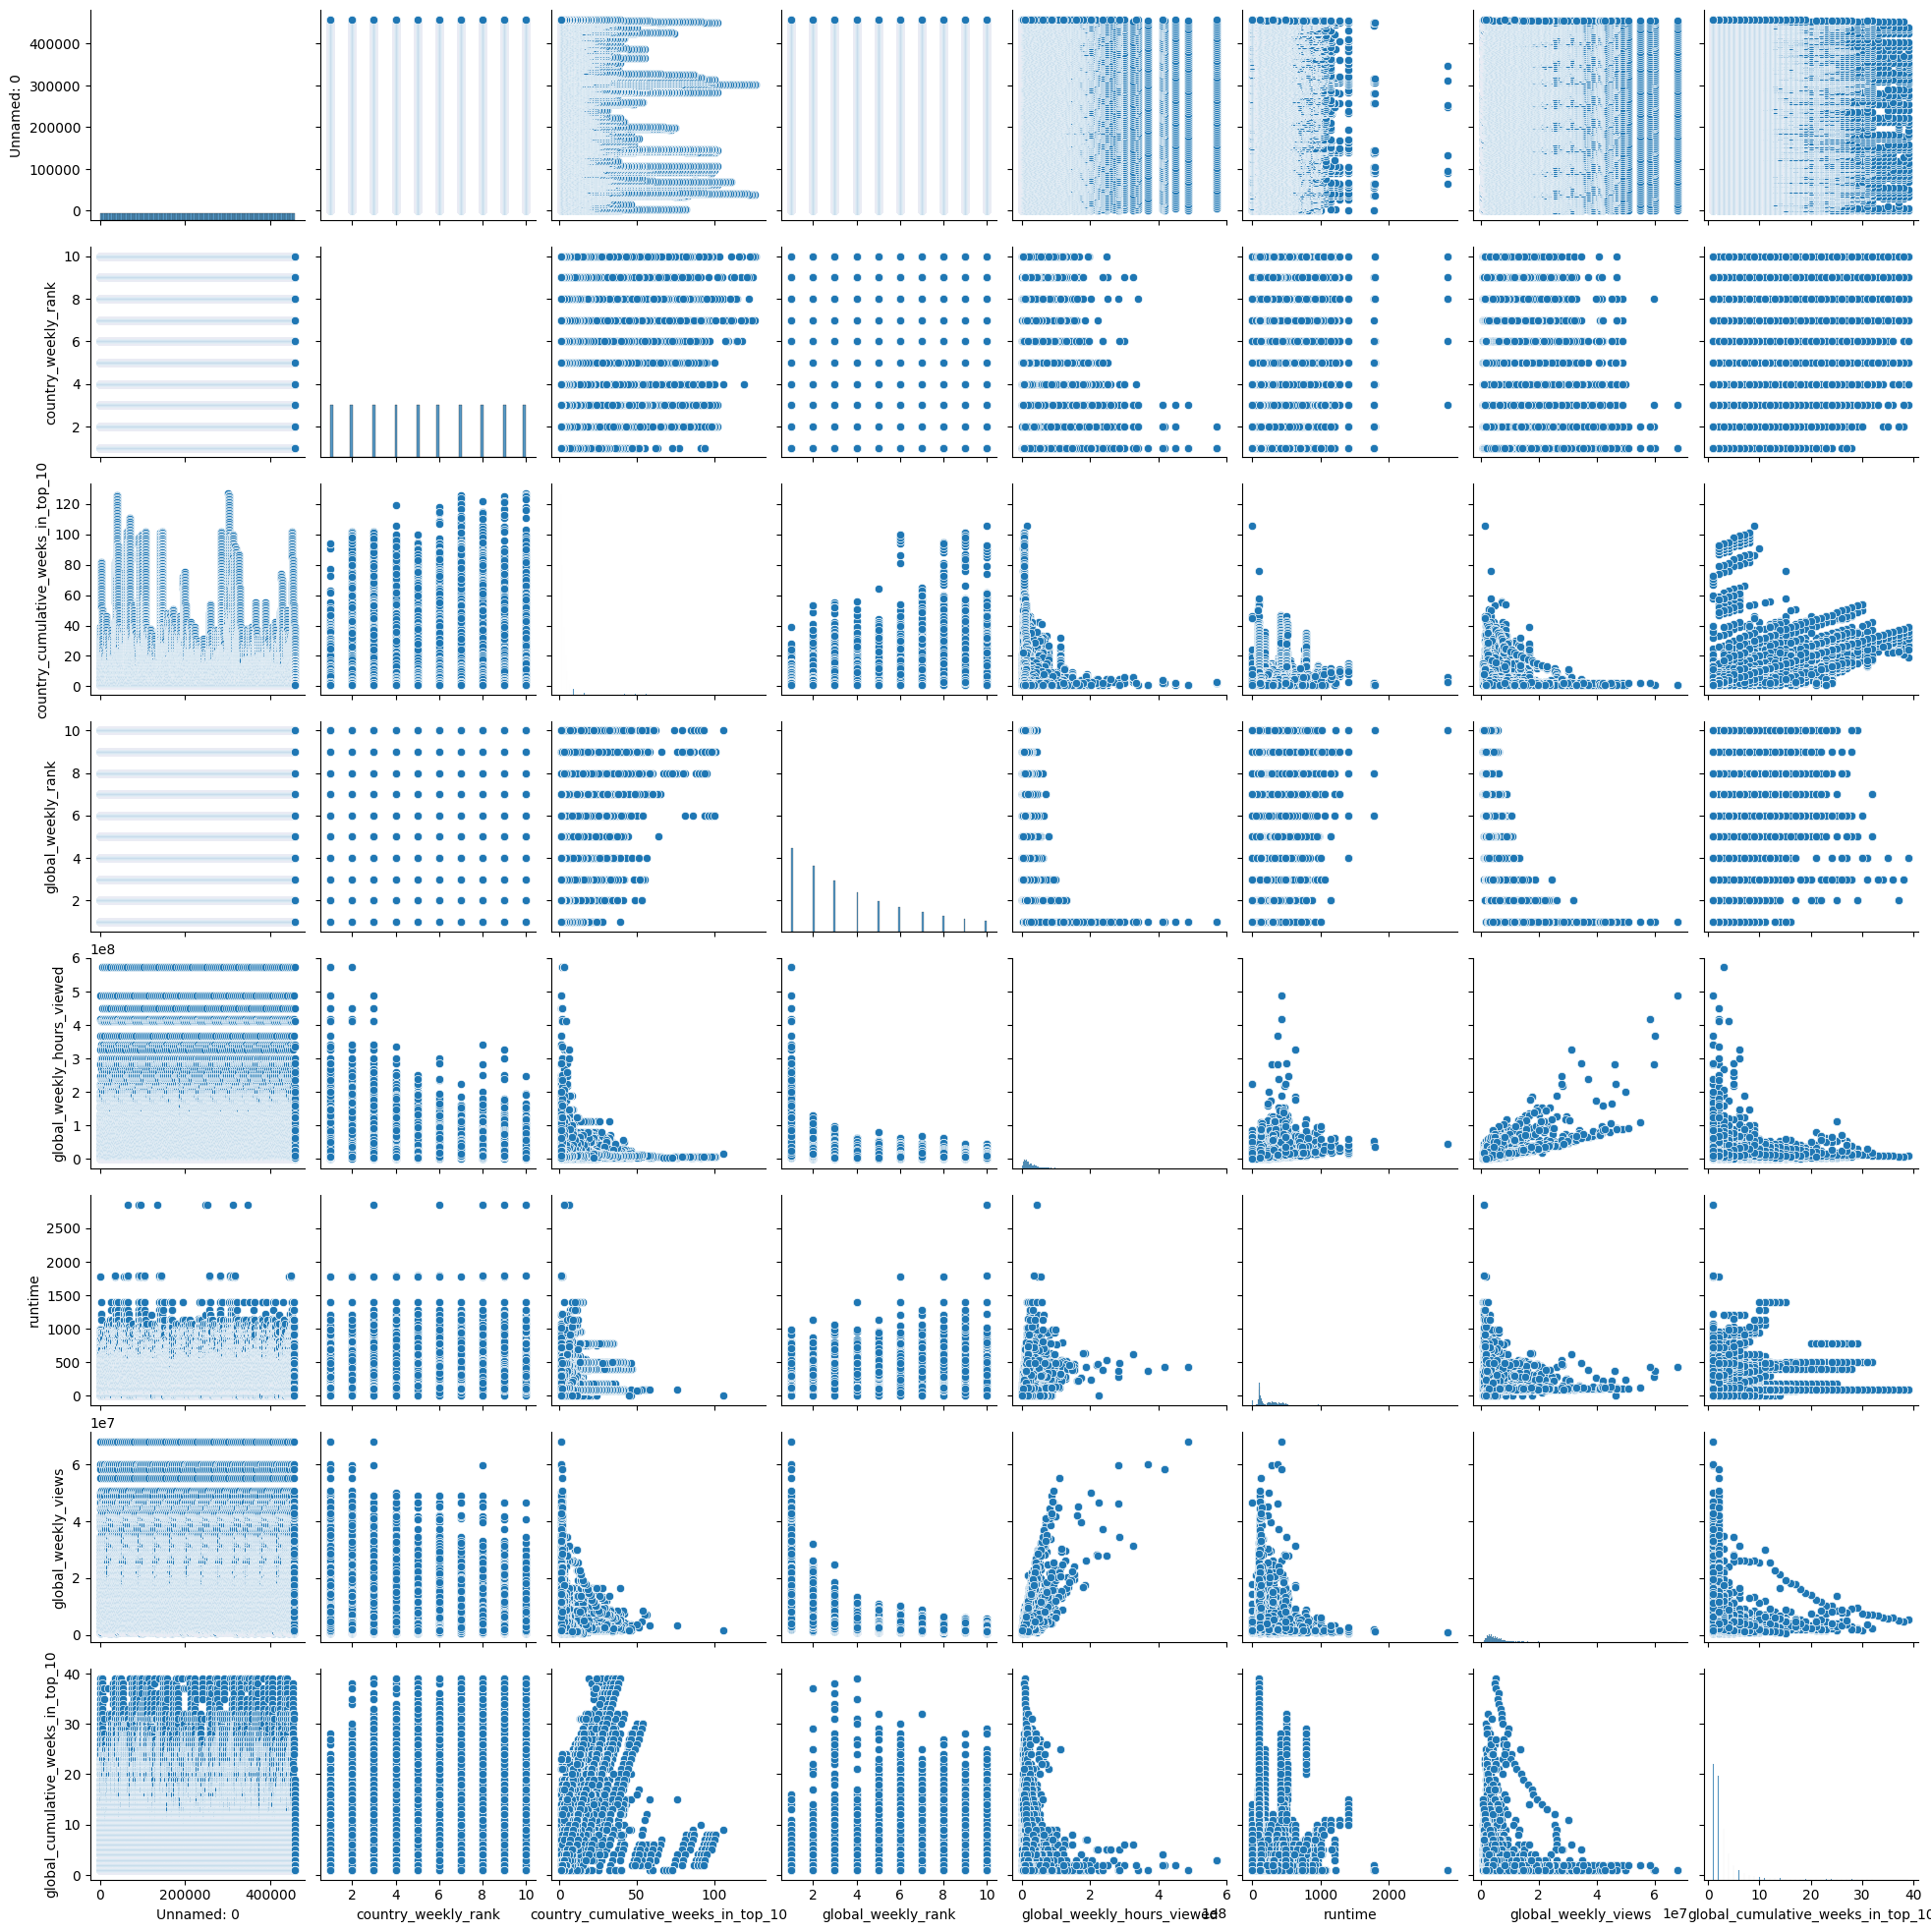

In [22]:
sns.pairplot(df)

Relationship of runtime and global weekly views

In [40]:
df_films_runtime = df.loc[(df.runtime < 240) & (df.country_category == "Films")]

Text(0, 0.5, 'Global weekly views')

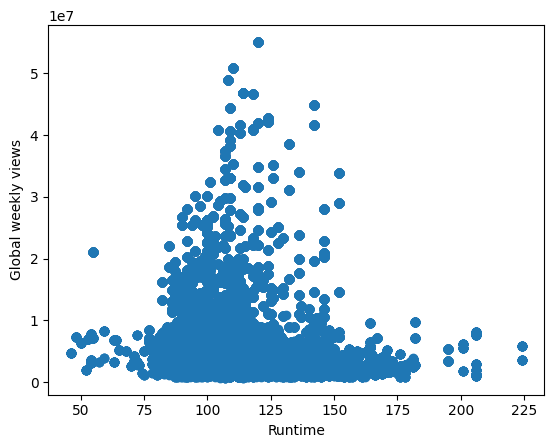

In [57]:
plt.scatter(x=df_films_runtime.runtime, y=df_films_runtime.global_weekly_views)
plt.xlabel('Runtime')
plt.ylabel('Global weekly views')

Normal distribution?

In [65]:
# What categories are there?
df.global_category.unique()

array(['Films (English)', 'Films (Non-English)', nan, 'TV (Non-English)',
       'TV (English)'], dtype=object)

In [71]:
df

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
458333,458333,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN
458334,458334,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1,NaN,NaN,NaN,NaN,NaN,NaN
458335,458335,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1,TV (English),2.0,62150000.0,NaN,NaN,1.0
458336,458336,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1,TV (Non-English),10.0,9140000.0,NaN,NaN,1.0
